## 1. Setup

In [40]:
import os
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import librosa
from tqdm.autonotebook import tqdm
from huggingface_hub import hf_hub_download

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import joblib
import matplotlib.pyplot as plt

N_FFT = 1 << 15
TARGET_SR = 44100
TRACK_DURATION = 10  # seconds
TEST_SIZE = 0.2
RANDOM_STATE = 67

os.makedirs("data", exist_ok=True)

## 2. Download Echoes dataset

In [41]:
ECHOES_DIR = "data/echoes"
MANIFEST_PATH = os.path.join(ECHOES_DIR, "dataset_manifest.csv")

if not os.path.exists(MANIFEST_PATH):
    zip_path = hf_hub_download(
        repo_id="Octavian97/Echoes", filename="Echoes.zip", repo_type="dataset"
    )
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(ECHOES_DIR)

manifest = pd.read_csv(MANIFEST_PATH)
print(f"AI tracks in manifest: {len(manifest)}")
print(
    f"Generators ({len(manifest['generator'].unique())}): {sorted(manifest['generator'].unique())}"
)
print(f"Types: {manifest['type'].unique()}")
print(f"Genres: {manifest['genre'].unique()}")
print(f"Total duration: {manifest['duration'].sum() / 3600:.1f} hours")

AI tracks in manifest: 3577
Generators (10): ['acestep', 'audioldm', 'brev', 'diffrhythm', 'mubert', 'producer', 'songgen', 'stableaudio', 'suno', 'udio']
Types: <StringArray>
['TTA', 'ATA']
Length: 2, dtype: str
Genres: <StringArray>
['Electronic', 'Rock', 'Pop']
Length: 3, dtype: str
Total duration: 110.2 hours


## 3. Download FMA small dataset

In [42]:
import glob

FMA_SMALL_DIR = "data/fma_small"

if not os.path.exists(FMA_SMALL_DIR):
    print("Downloading fma_small ...")
    urllib.request.urlretrieve(
        "https://os.unil.cloud.switch.ch/fma/fma_small.zip",
        "data/fma_small.zip",
    )
    with zipfile.ZipFile("data/fma_small.zip") as zf:
        zf.extractall("data")
    os.remove("data/fma_small.zip")

real_files = sorted(
    glob.glob(os.path.join(FMA_SMALL_DIR, "**", "*.mp3"), recursive=True)
)
print(f"Real tracks: {len(real_files)}")

Real tracks: 8000


## 4. Process audio

In [43]:
CACHE_REAL = "data/real.npy"
CACHE_FAKE = "data/fake.npy"


def process_audio(file_list, output=None):
    result = []

    for f in tqdm(file_list, desc="Processing audio"):
        try:
            y, sr = librosa.load(f, sr=TARGET_SR, duration=TRACK_DURATION, mono=True)
        except Exception:
            continue

        stft = np.abs(librosa.stft(y, n_fft=N_FFT)) ** 2
        stft_db = 10 * np.log10(np.clip(stft, 1e-10, 1e9))
        mean = stft_db.mean(axis=1)
        diff = np.diff(mean)
        result.append(diff)

    result = np.array(result)

    if output is not None:
        np.save(output, result)
        print(f"Cached to {output}")

    return result


if os.path.exists(CACHE_REAL):
    print("Loading cached real features ...")
    x_real = np.load(CACHE_REAL)
else:
    x_real = process_audio(real_files, CACHE_REAL)

ai_files = [os.path.join(ECHOES_DIR, row["path_in_dataset"]) for _, row in manifest.iterrows()]
ai_generators = manifest["generator"].values
if os.path.exists(CACHE_FAKE):
    print("Loading cached AI features ...")
    x_fake = np.load(CACHE_FAKE)
else:
    x_fake = process_audio(ai_files, CACHE_FAKE)

print(f"Real features: {x_real.shape}, AI features: {x_fake.shape}")

Loading cached real features ...
Loading cached AI features ...
Real features: (7997, 16384), AI features: (3577, 16384)


## 5. Split datasets to test / train sets

In [44]:
x = np.concatenate([x_real, x_fake], axis=0)
y = np.concatenate([np.zeros(len(x_real)), np.ones(len(x_fake))], axis=0)
g = np.concatenate([np.full(len(x_real), ""), ai_generators], axis=0)

x_train, x_test, y_train, y_test, g_train, g_test = train_test_split(
    x, y, g, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(y_train)} ({sum(y_train == 0)} real, {sum(y_train == 1)} AI)")
print(f"Test:  {len(y_test)} ({sum(y_test == 0)} real, {sum(y_test == 1)} AI)")

Train: 9259 (6397 real, 2862 AI)
Test:  2315 (1600 real, 715 AI)


## 6. Train PCA + XGBoost

In [45]:
os.makedirs("models", exist_ok=True)

pca = PCA(n_components=512, random_state=RANDOM_STATE)
scale_pos = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
xgb = XGBClassifier(
    learning_rate=0.05,
    n_estimators=600,
    eval_metric="logloss",
    scale_pos_weight=scale_pos,
    random_state=RANDOM_STATE,
)

print("Fitting PCA ...")
x_tr = pca.fit_transform(x_train)
print("Training XGBoost ...")
xgb.fit(x_tr, y_train)
joblib.dump(pca, "models/pca.joblib")
xgb.save_model("models/xgb.json")


Fitting PCA ...
Training XGBoost ...


## 7. Evaluation

              precision    recall  f1-score   support

      Not AI     0.9863    0.9912    0.9888      1600
          AI     0.9802    0.9692    0.9747       715

    accuracy                         0.9844      2315
   macro avg     0.9833    0.9802    0.9817      2315
weighted avg     0.9844    0.9844    0.9844      2315



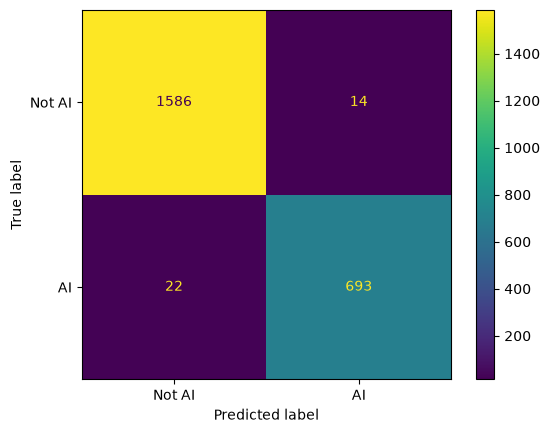

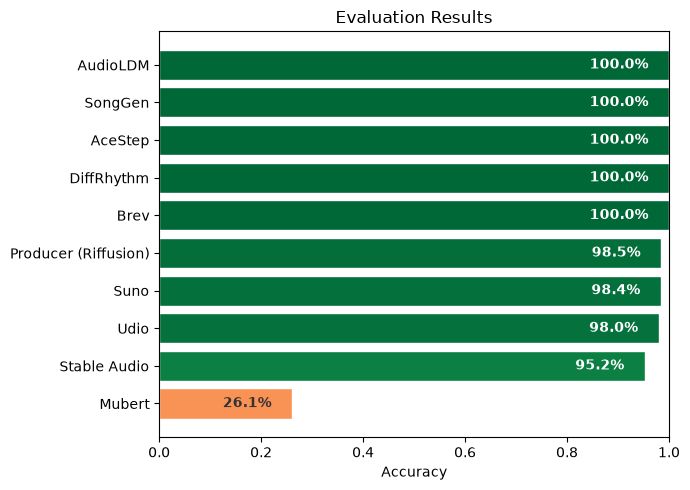

In [46]:
xgb = XGBClassifier()
xgb.load_model("models/xgb.json")
pca = joblib.load("models/pca.joblib")

x_te = pca.transform(x_test)
y_pred = xgb.predict(x_te)

print(classification_report(y_test, y_pred, target_names=["Not AI", "AI"], digits=4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Not AI", "AI"])
plt.show()

providers = sorted(np.unique(g_test[g_test != ""]))
accuracies = [np.mean(y_pred[g_test == p] == y_test[g_test == p]) for p in providers]

order = np.argsort(accuracies)
providers = [providers[i] for i in order]
accuracies = [accuracies[i] for i in order]

provider_names = {
    "acestep": "AceStep",
    "audioldm": "AudioLDM",
    "brev": "Brev",
    "diffrhythm": "DiffRhythm",
    "mubert": "Mubert",
    "producer": "Producer (Riffusion)",
    "songgen": "SongGen",
    "stableaudio": "Stable Audio",
    "suno": "Suno",
    "udio": "Udio",
}
display_names = [provider_names[p] for p in providers]

plt.figure(figsize=(7, 5))
plt.title("Evaluation Results")
bars = plt.barh(
    display_names, accuracies, color=plt.cm.RdYlGn(accuracies), edgecolor="white"
)
plt.xlim(0, 1)
plt.xlabel("Accuracy")

for bar, acc in zip(bars, accuracies):
    x = bar.get_width() - 0.04
    ha = "right"
    if acc < 0.15:
        x = bar.get_width() + 0.02
        ha = "left"
    plt.text(
        x,
        bar.get_y() + bar.get_height() / 2,
        f"{acc:.1%}",
        ha=ha,
        va="center",
        color="white" if acc > 0.4 else "#333",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()